In [71]:
import math
import matplotlib.pyplot as plt
import gprsim
import numpy as np

In [72]:
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.figsize': (8, 6) # Adjust figure size
})

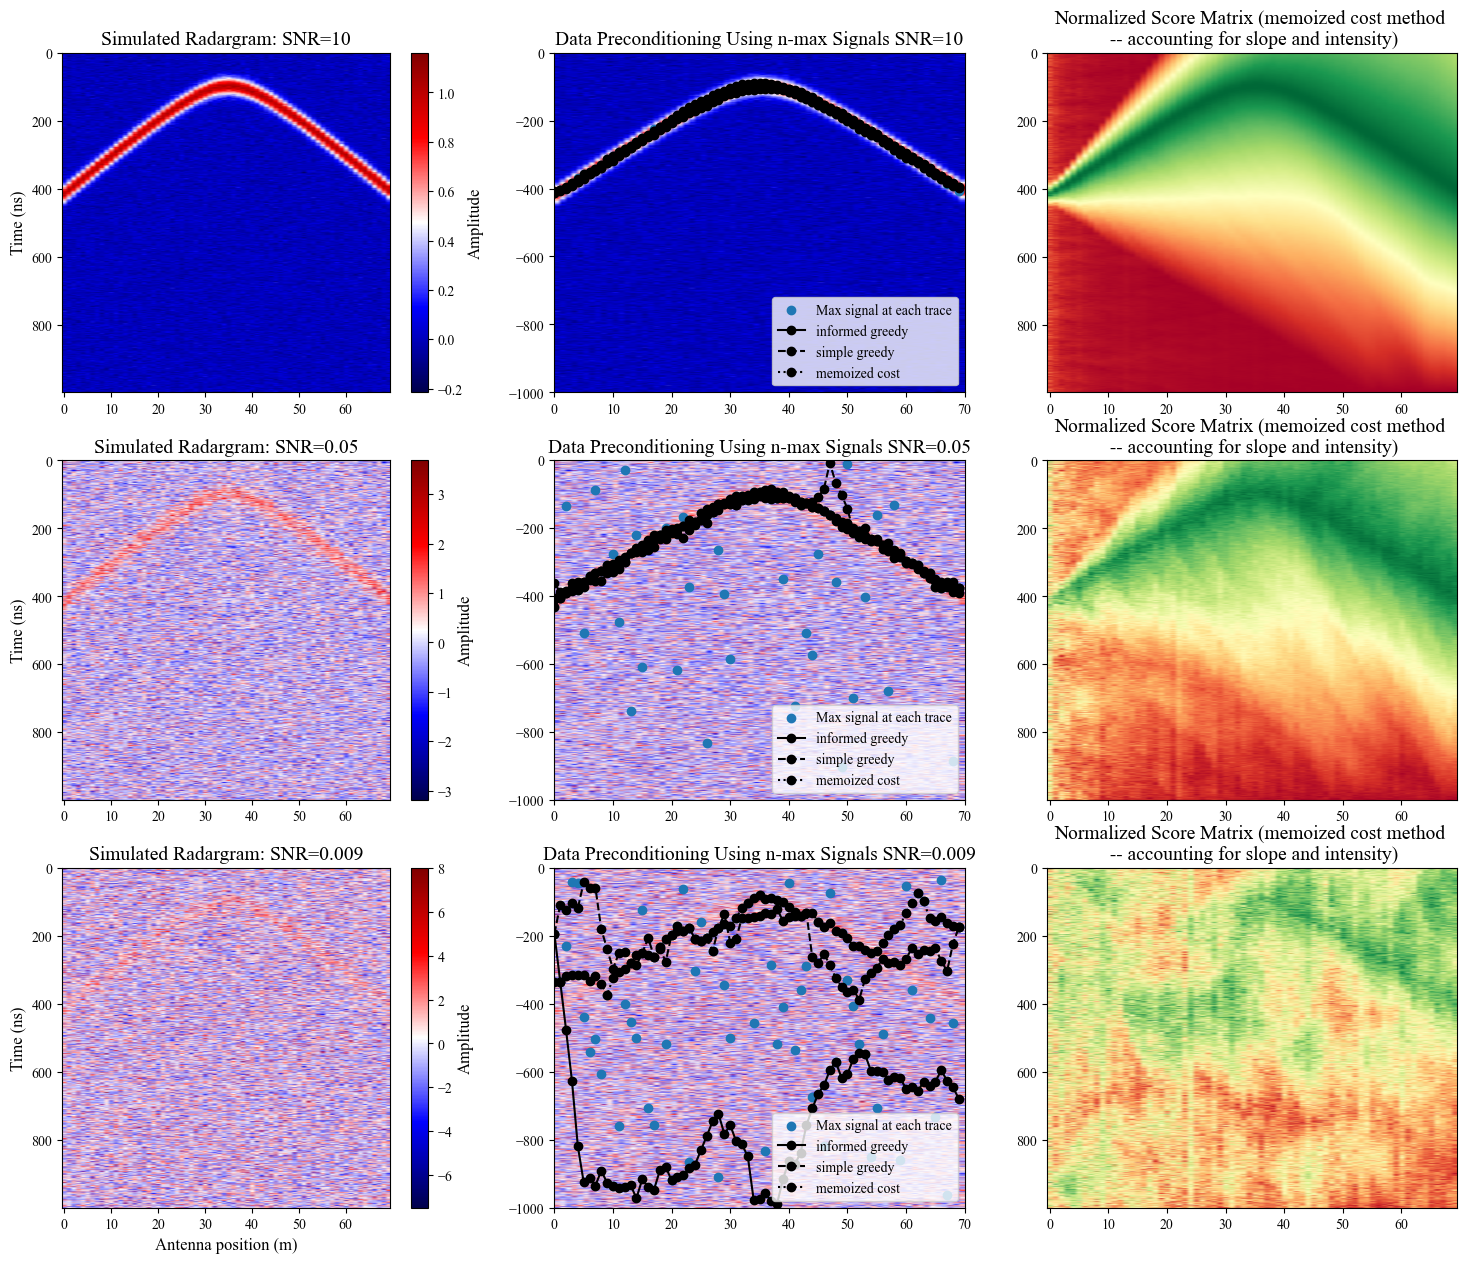

In [73]:
def visualize_preconditioning():
    fig, ax = plt.subplots(3, 3, figsize=(18,15))
    
    for SNR, i in zip([10, 0.05, 0.009], range(0,3)):
        # Parameters
        eps_r = 3                  # relative dielectric permittivity
        rf = 40e6                 # radar frequency different from pulse frequency
        dt = 1e-9                  # seconds
        dx = 1                     # meters
        region_shape = (70, 1e-6)  # grid (x,z)
        wavetype = 'gaussian'
        
        # Point reflectors at (x,t) where x [m] and t [s]
        reflectors = [(35, 50e-9)]
        
        data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR)
        
        im = ax[i][0].imshow(data, aspect='auto', cmap='seismic')
        if i == 2:
            ax[i][0].set_xlabel("Antenna position (m)")
        ax[i][0].set_ylabel("Time (ns)")
        ax[i][0].set_title(f"Simulated Radargram: SNR={SNR}")
        cbar = fig.colorbar(im, label="Amplitude")
        
        t, x = data.argsort(axis=0)[::-1,:][0], np.arange(0, data.shape[1]) * dx 
        x_window, t_window = gprsim.minimize_tracewise_slope_window(data, 20, 1, 5)
        x_greedy, t_greedy = gprsim.minimize_tracewise_slope_greedy(data, 15, dx)
        x_dynamic, t_dynamic, c, b = gprsim.smooth_path_dp(data, dx, lam=0.001)
        
        ax[i][1].set_title(f"Data Preconditioning Using n-max Signals SNR={SNR}")
        im1 = ax[i][1].imshow(data, aspect='auto', extent=[0,70,-1000,0], cmap='seismic')
        ax[i][1].scatter(x, -t, label="Max signal at each trace")
        ax[i][1].plot(x_window, -t_window, label="informed greedy", c='black', linestyle='-')
        ax[i][1].plot(x_greedy, -t_greedy, label="simple greedy", c='black', linestyle='--')
        ax[i][1].plot(x_dynamic, t_dynamic, label="memoized cost", c='black', linestyle=':')
        ax[i][1].legend(loc="lower right")
    
    
        im2 = ax[i][2].imshow((c-c.min(axis=0))/(c.max(axis=0)-c.min(axis=0)), aspect='auto', cmap='RdYlGn')
        ax[i][2].set_title("Normalized Score Matrix (memoized cost method \n -- accounting for slope and intensity)")
visualize_preconditioning()

## A really noisy simulation

Text(0.5, 235.72222222222223, 'x distance (m)')

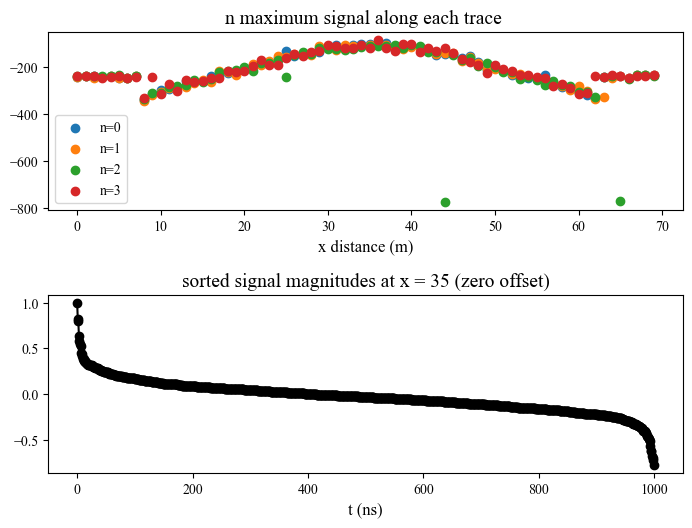

In [25]:
eps_r = 3                  # relative dielectric permittivity
rf = 400e6                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
region_shape = (70, 1e-6)  # grid (x,z)
wavetype = 'gaussian'
SNR = 0.02

# Point reflectors at (x,t) where x [m] and t [s]
reflectors = [(35, 50e-9)]

data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR, long_reflectors=[])

fig, ax = plt.subplots(2, figsize = (7,5))
fig.tight_layout(h_pad=4)

for n in range(0,4):
    t = data.argsort(axis=0)[::-1,:][n]* -1 # Ttake the indices of the max 5 signals
    x = np.arange(0, data.shape[1]) * dx # 
    ax[0].scatter(x, t, label=f"n={n}")

sample_signal = data[:,35]
ax[1].plot(np.sort(sample_signal)[::-1], c='black')
ax[1].set_title("sorted signal magnitudes at x = 35 (zero offset)")
ax[1].set_xlabel("t (ns)")
ax[0].legend()
ax[0].set_title("n maximum signal along each trace ")
ax[0].set_xlabel("x distance (m)")

# This looks quite nice, Lets gradually degrade the SNR ot see how the alg responds

In [182]:
# Parameters
eps_r = 3                  # relative dielectric permittivity
rf = 400e6                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
region_shape = (70, 1e-6)  # grid (x,z)
wavetype = 'gaussian'
# Point reflectors at (x,t) where x [m] and t [s]
reflectors = [(35, 50e-9)]
x_0, t_0 = reflectors[0][0], reflectors[0][1]

drs = []
dx0s = []
dt0s = []
for SNR in np.arange(0.0009,0.2,0.002):
    data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR)
    v, z, x0, t0 = gprsim.fit_hyperbola(data, 1, 'robust_fit', dx, dt, lam=0.001)
    drs.append(((np.abs(eps_r-(3e8/v)**2)) / ((np.abs(eps_r+(3e8/v)**2))/2))*100)
    dx0s.append(((np.abs(x_0-x0)) / ((np.abs(x_0+x0)/2)))*100)
    dt0s.append(((np.abs(t_0-t0)) / ((np.abs(t_0+t0)/2)))*100)
        

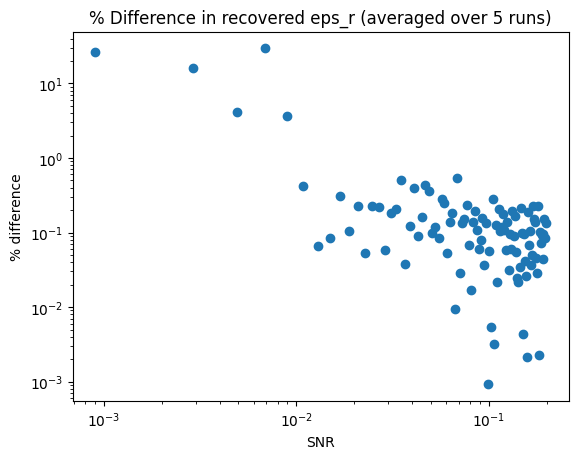

In [187]:
plt.scatter(np.arange(0.0009,0.2,0.002), drs); plt.title("% Difference in recovered eps_r (averaged over 5 runs)"); plt.xlabel("SNR"); plt.ylabel("% difference"); plt.xscale('log'); plt.yscale('log'); 


Caught invalud value in sqrt: can not calculate hyperbola parameters from pinv. Switching to np.polyfit to avoid distruption. If np.polyfit quits, the input data may be too noisy


AttributeError: 'float' object has no attribute 'argmax'

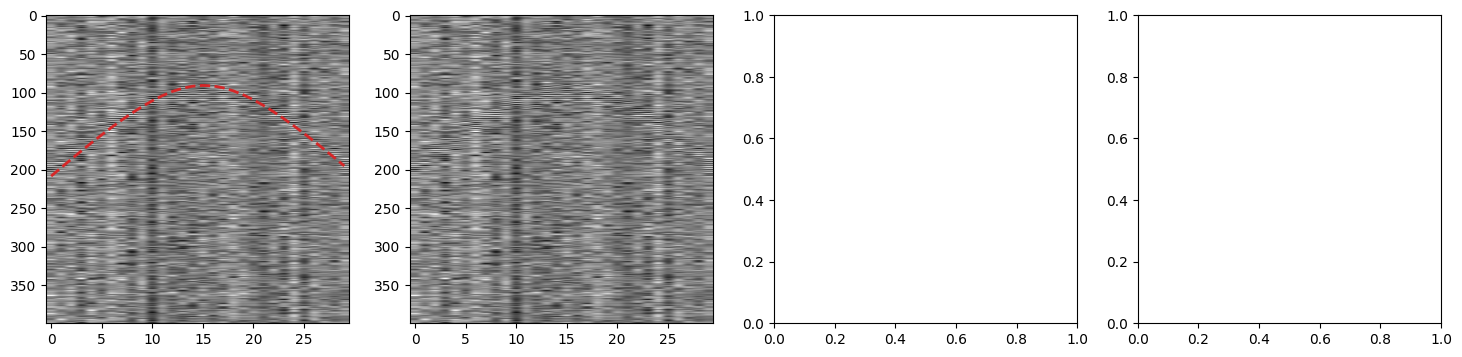

In [23]:
from gprsim import smooth_path_dp
from gprsim import fit_hyperbola
fig, ax = plt.subplots(1,4, figsize=(18,4))
# Parameters
eps_r = 3                  # relative dielectric permittivity
rf = 400e6                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
nx = 70
nt = 1e-6
region_shape = (nx, nt)  # grid (x,z)
wavetype = 'gaussian'
SNR = 0.1

# Point reflectors at (x,t) where x [m] and t [s]
reflectors = [(35, 50e-9)]

data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR)
data = data[0:400, 20:50]
# im = ax[0].imshow(c-c.mean(axis=0), aspect="auto")
# im = ax[0].imshow(data, aspect="auto", cmap='binary', alpha=0.4)
# im2 = ax[1].imshow(data, aspect="auto", cmap='binary', alpha=0.4)
# im3 = ax[2].imshow(data, aspect="auto", cmap='binary', alpha=0.4)

'''
Plot the intensity only case
'''
x, t, c, b = smooth_path_dp(data, dx, lam=0) # Intensity only path
ax[0].imshow((c-c.min(axis=0))/(c.max(axis=0)-c.min(axis=0)),cmap='binary', aspect='auto')
v, z, x0, t0 = fit_hyperbola(data, 1, 'robust_fit', dx, dt, x, t)
ax[0].plot(x, (2*np.sqrt((x-x0)**2 + z**2))/(v*1e-9), c='tab:red', ls='--', lw=2)

'''
Plot the slope only case
'''
x, t, c, b = smooth_path_dp(data, dx, lam=1)
ax[1].imshow((c-c.min(axis=0))/(c.max(axis=0)-c.min(axis=0)),cmap='binary', aspect='auto')
v, z, x0, t0 = fit_hyperbola(data, 1, 'robust_fit', dx, dt, x, t)
ax[1].plot(x, (2*np.sqrt((x-x0)**2 + z**2))/(v*1e-9), c='tab:blue', ls='--', lw=2)

'''rfd
plot the optimal case
'''
# x, t, c, b = smooth_path_dp(data, dx, lam=0.001)
# ax[2].imshow((c-c.min(axis=0))/(c.max(axis=0)-c.min(axis=0)),cmap='binary', aspect='auto')
# v, z, x0, t0 = fit_hyperbola(data, 1, 'robust_fit', dx, dt, 0.001)
# ax[2].plot(x, (2*np.sqrt((x-x0)**2 + z**2))/(v*1e-9), c='y', ls='--', lw=2)
x, t = gprsim.minimize_tracewise_slope_window(data, 100, dx, 5)
v, z, x0, t0 = fit_hyperbola(data, 1, 'robust_fit', dx, dt, x, t)
ax[2].imshow((c-c.min(axis=0))/(c.max(axis=0)-c.min(axis=0)),cmap='binary', aspect='auto')
ax[2].plot(x, (2*np.sqrt((x-x0)**2 + z**2))/(v*1e-9), c='y', ls='--', lw=2)


ax[3].imshow(data, aspect="auto", cmap='seismic')



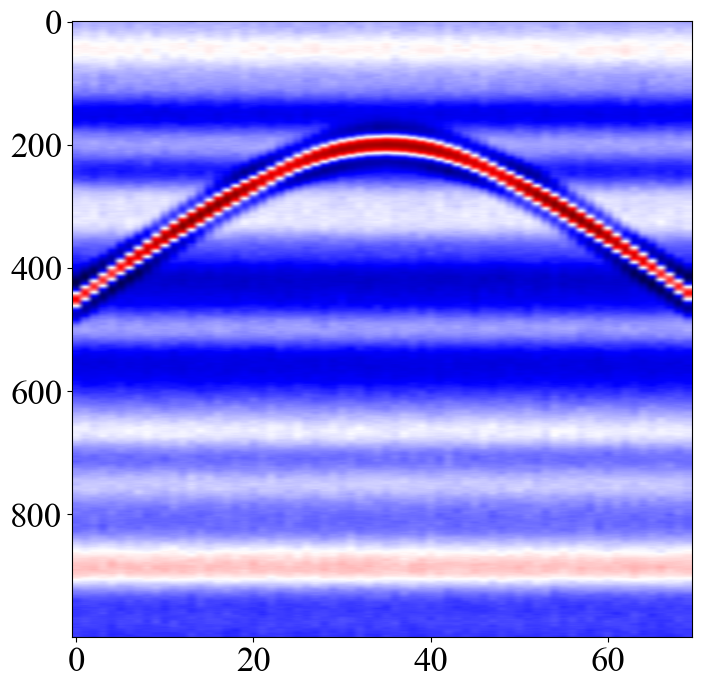

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import gprsim
from scipy.interpolate import interp1d

eps_r = 3                  # relative dielectric permittivity
rf = 15e6                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
nx = 70
nt = 1e-6
region_shape = (nx, nt)  # grid (x,z)
wavetype = 'gaussian'
SNR = 5

# Point reflectors at (x,t) where x [m] and t [s]
reflectors = [(35, 100e-9)]

data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR)
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.figsize': (8, 6) # Adjust figure size
})
fig = plt.figure(figsize=(8,8))
plt.imshow(data, aspect='auto', cmap='seismic')


# Try something new

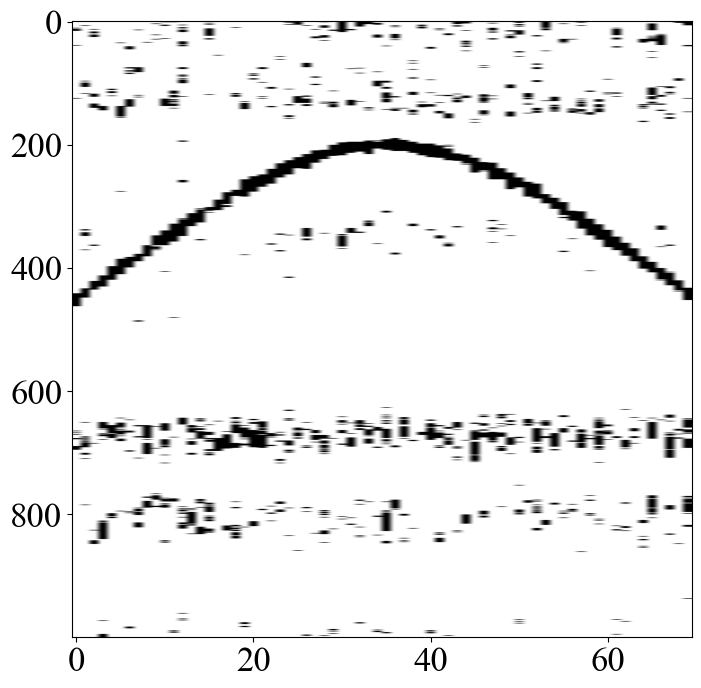

In [50]:
threshold = np.mean(data[np.where(data>data.max()*0.2)])
data_binary = np.zeros_like(data)
data_binary[np.where(data>threshold)] = 1
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.figsize': (8, 6) # Adjust figure size
})
fig = plt.figure(figsize=(8,8))
plt.imshow(data_binary, aspect='auto', cmap='binary')

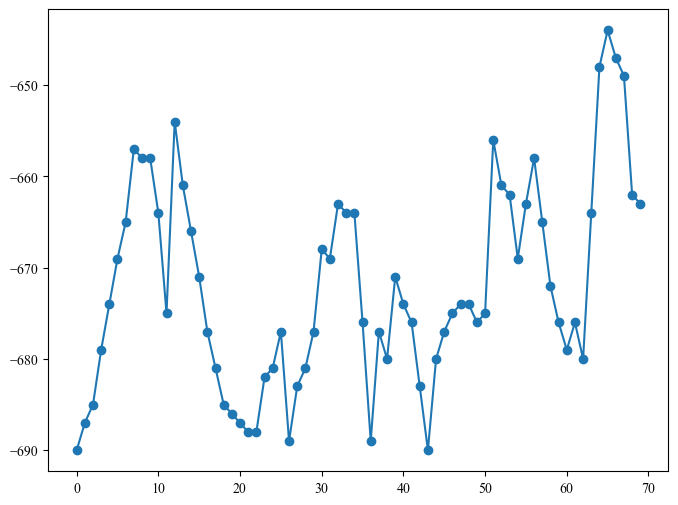

In [53]:
x, y, c, b = gprsim.smooth_path_dp(data_binary, dx, 0.001)
plt.plot(x, y)

# Lets begin Testing some simple migration teqniques

## 1. Kirchhoff by diffraction summation

First, lets make an example GPR section with some toy reflector 

Text(0, 0.5, 'twt (ns)')

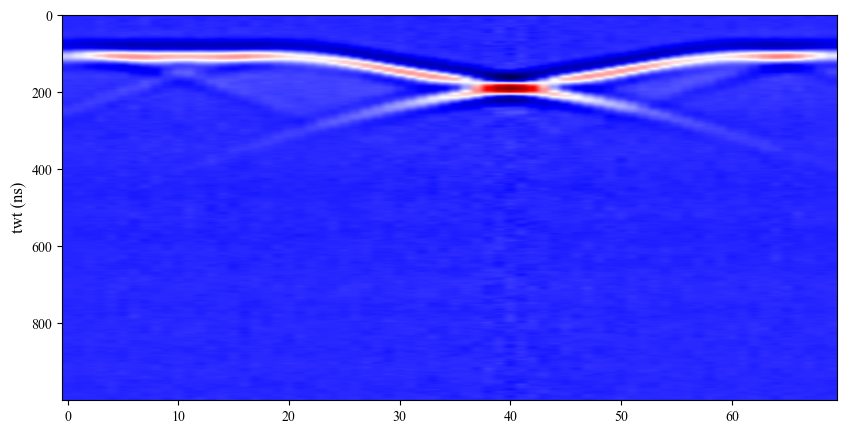

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import gprsim
from scipy.interpolate import interp1d

eps_r = 3                  # relative dielectric permittivity
rf = 15e6                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
Xlim = 70
Tlim = 1e-6
region_shape = (Xlim, Tlim)  # grid (x,z)
Nx, Nt = int(Xlim/dx), int(Tlim/dt)
wavetype = 'gaussian'
SNR = 5

# Point reflectors at (x,t) where x [m] and t [s]
# array list concatornation of two point reflectors and a dipper
reflectors = gprsim.dipping_reflector((0, 50e-9), (20, 50e-9))+gprsim.dipping_reflector((20, 50e-9), (40, 100e-9))+gprsim.dipping_reflector((40, 100e-9), (60, 50e-9))+gprsim.dipping_reflector((60, 50e-9), (70, 50e-9))
data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR, long_reflectors=[])

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.figsize': (8, 6) # Adjust figure size
})
fig, ax = plt.subplots(figsize = (10, 5))
ax.imshow(gprsim.norm2d(data), aspect='auto', cmap='seismic')
ax.set_ylabel("twt (ns)")

Now apply Kirchhoff migration diffraction summation

In [16]:
gprsim.dipping_reflector((40, 20), (60, 10))

[(40, 20.0),
 (41, 19.5),
 (42, 19.0),
 (43, 18.5),
 (44, 18.0),
 (45, 17.5),
 (46, 17.0),
 (47, 16.5),
 (48, 16.0),
 (49, 15.5),
 (50, 15.0),
 (51, 14.5),
 (52, 14.0),
 (53, 13.5),
 (54, 13.0),
 (55, 12.5),
 (56, 12.0),
 (57, 11.5),
 (58, 11.0),
 (59, 10.5),
 (60, 10.0)]

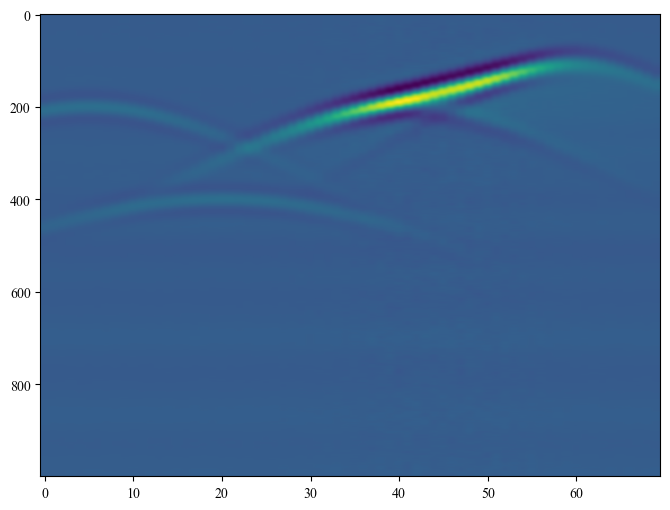

In [27]:
eps_r = 3                  # relative dielectric permittivity
rf = 15e6                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
Xlim = 70
Tlim = 1e-6
region_shape = (Xlim, Tlim)  # grid (x,z)
Nx, Nt = int(Xlim/dx), int(Tlim/dt)
wavetype = 'gaussian'
SNR = 20

# Point reflectors at (x,t) where x [m] and t [s]
# array list concatornation of two point reflectors and a dipper
reflectors = [(5, 100e-9), (20, 200e-9)]+gprsim.dipping_reflector((40, 100e-9), (60, 50e-9))
data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR, long_reflectors=[])
def Kichhoff(data, eps_r, Tlim, Nt, t_samples, x_positions):
    # --- Velocity model (constant) ---
    c0 = 3e8
    v = c0 / np.sqrt(eps_r)
    
    # --- Output migration grid ---
    x_img = x_positions.copy()       # same as input x
    z_img = np.linspace(0, v*Tlim/2, Nt) # converting time window to max depth: z_max = v * t_max / 2
    
    migrated = np.zeros((len(x_img), len(z_img)))
    
    # --- Migration Loop ---
    for ix, x in enumerate(x_img):
        for iz, z in enumerate(z_img):
    
            # Travel time curve T(x_s; x,z) for all traces
            # Two-way travel time in constant velocity
            T = 2.0 * np.sqrt((x_positions - x)**2 + z**2) / v
    
            # Only use times inside the data window
            valid = (T >= t_samples[0]) & (T <= t_samples[-1])
            if not np.any(valid):
                continue
                
            # Interpolate each trace’s data at time T
            amplitudes = np.zeros_like(T)
            for isrc in np.where(valid)[0]:
                f = interp1d(t_samples, data[:, isrc], kind='linear', fill_value=0, bounds_error=False)
                amplitudes[isrc] = f(T[isrc])
    
            # Sum contributions (simplest Kirchhoff)
            migrated[ix, iz] = np.sum(amplitudes)
           
    return migrated
plt.imshow(data, aspect='auto')

KeyboardInterrupt: 

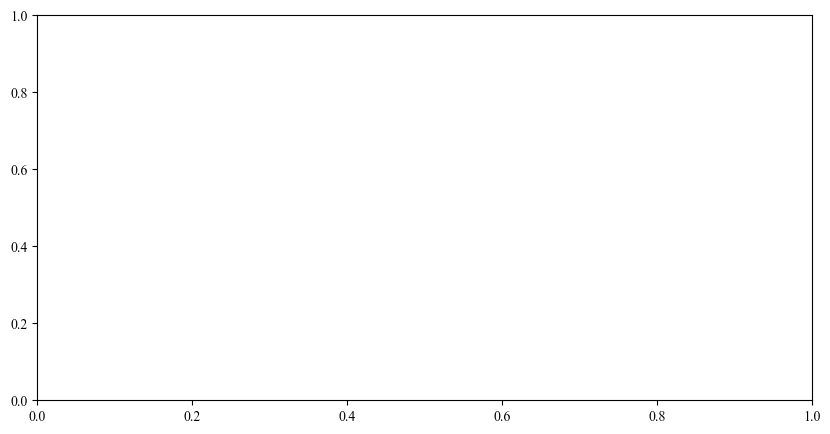

In [28]:
def norm2d(array):
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Apply the normalization formula
    normalized_array = 2 * ((array - min_val) / (max_val - min_val)) - 1
    
    return normalized_array
    
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.figsize': (8, 6) # Adjust figure size
})
fig, ax = plt.subplots(figsize = (10, 5))
ax.imshow(norm2d(Kichhoff(data, eps_r, Tlim, Nt, t_samples, x_positions).T), aspect='auto', extent=[x_img.min(), x_img.max(), z_img.max(), z_img.min()],cmap='seismic')
# --- Plot result ---
# ax.set_title("Kirchhoff Migrated Section")
# ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

Interesting stuff. Though this works his is very computationally intesive and seems to amplify noise around the reflector

This is much faster, but relies on a constant velocity medium

In [29]:
import migration
c0 = 3e8
v = c0 / np.sqrt(eps_r)
Dmig, tmig, xmig = migration.fkmig(data, dt, dx, v)

In [30]:
Dmig.min()

-0.7081750036697939

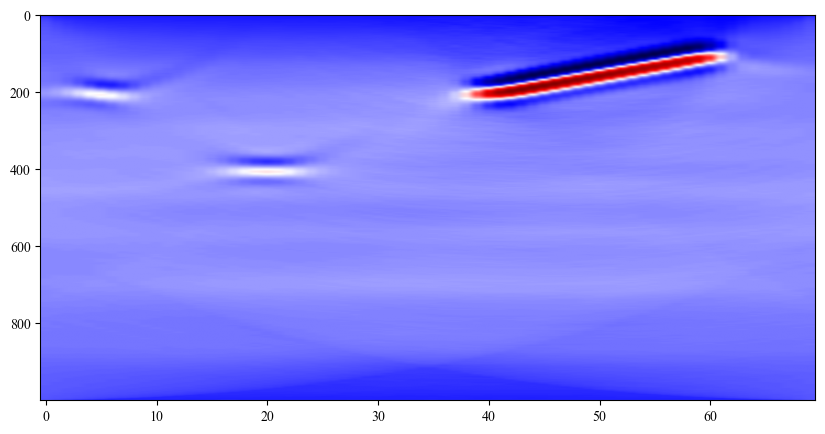

In [37]:
fig, ax = plt.subplots(figsize = (10, 5))
ax.imshow(Dmig, aspect="auto", cmap='seismic')